<a href="https://colab.research.google.com/github/HakumenWorld/Digital-Skola/blob/main/%5BFebi_Kristiana_DS_Batch_60%5D_Conqueror_Project_I.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Churn Analysis (Data Science Project)

# 1.&nbsp;Import relevant libraries

In [5]:
# Standard libraries for data analysis:
import numpy as np
import pandas as pd
pd.options.display.max_columns = None
from pandas.plotting import scatter_matrix
from scipy.stats import norm, skew

# sklearn modules for data preprocessing
from sklearn.preprocessing import (
    LabelEncoder,
    StandardScaler,
)
from sklearn.model_selection import train_test_split

# sklearn modules for Model Selection
from sklearn.neighbors import KNeighborsClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier


# sklearn modules for Model Evaluation & Improvement
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    fbeta_score
)

from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.model_selection import (
    cross_val_score,
    GridSearchCV,
    ShuffleSplit,
    KFold
)

# Standard libraries for data visualization
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.pylab as pylab
import seaborn as sns
%matplotlib inline
color = sns.color_palette()
import matplotlib.ticker as mtick
from IPython.display import display

# Miscellaneous Utilitiy Libraries
import random
from datetime import datetime
import string

In [6]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# 2.&nbsp;Import dataset

In [7]:
# Import the dataset
file_dir = "/content/drive/MyDrive/Digital Skola/customer_churn_data.csv" # Sesuaikan!
dataset = pd.read_csv(file_dir)

# Read Dataset
display(dataset)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes


## 2.1. Check Missing Values

In [8]:
dataset.isna().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


## 2.2. Check Duplicate

In [9]:
flag_duplicate_rows = dataset.duplicated(
    subset=None,
    keep=False
)
dataset[flag_duplicate_rows].sort_values(
    by=list(dataset.columns),
    axis=0,
)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn


In [10]:
flag_duplicate_rows.sum()

np.int64(0)

# 3.&nbsp;Evaluate Data Structure

In [11]:
# Evaluate data structure
dataset.describe(percentiles=[0.75])

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [12]:
dataset.dtypes

,0
customerID,object
gender,object
SeniorCitizen,int64
Partner,object
Dependents,object
tenure,int64
PhoneService,object
MultipleLines,object
InternetService,object
OnlineSecurity,object


Notes: TotalCharges harusnya data numerikal!

In [13]:
data_desc = (
    dataset
    .columns
    .to_series()
    .groupby(dataset.dtypes)
    .groups
    .items()
)

data_desc

dict_items([(dtype('int64'), Index(['SeniorCitizen', 'tenure'], dtype='object')), (dtype('float64'), Index(['MonthlyCharges'], dtype='object')), (dtype('O'), Index(['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService',
       'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
       'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
       'Contract', 'PaperlessBilling', 'PaymentMethod', 'TotalCharges',
       'Churn'],
      dtype='object'))])

In [14]:
# Recheck Column Datatypes and Missing Values:
data_desc = (
    dataset
    .columns
    .to_series()
    .groupby(dataset.dtypes)
    .groups
    .items()
)

for dtype, columns in data_desc:
    print(f"{dtype}:")
    for col in columns:
        print(f"  - {col}")

int64:
  - SeniorCitizen
  - tenure
float64:
  - MonthlyCharges
object:
  - customerID
  - gender
  - Partner
  - Dependents
  - PhoneService
  - MultipleLines
  - InternetService
  - OnlineSecurity
  - OnlineBackup
  - DeviceProtection
  - TechSupport
  - StreamingTV
  - StreamingMovies
  - Contract
  - PaperlessBilling
  - PaymentMethod
  - TotalCharges
  - Churn


In [15]:
# check missing values
dataset.isna().any()

,0
customerID,False
gender,False
SeniorCitizen,False
Partner,False
Dependents,False
tenure,False
PhoneService,False
MultipleLines,False
InternetService,False
OnlineSecurity,False


In [16]:
def unique_categorical_values(dataset, column_name):

    """
    Prints the number and list of unique values for a specified
    categorical column in a Pandas DataFrame.

    Args:
        dataset (pd.DataFrame): The Pandas DataFrame.
        column_name (str): The name of the categorical column.

    Returns:
        None
    """

    if dataset[column_name].dtype != 'object':
        print(f"Error: Column '{column_name}' is not a categorical column.")
    else:
        try:
            print(f"Number of unique {column_name}: {dataset[column_name].nunique()}")
            print(f"Unique {column_name}:")
            for value in dataset[column_name].unique():
                print(f"- {value}")
        except KeyError:
            print(f"Error: Column '{column_name}' not found in the dataset.")

In [17]:
help(unique_categorical_values)

Help on function unique_categorical_values in module __main__:

unique_categorical_values(dataset, column_name)
    Prints the number and list of unique values for a specified
    categorical column in a Pandas DataFrame.

    Args:
        dataset (pd.DataFrame): The Pandas DataFrame.
        column_name (str): The name of the categorical column.

    Returns:
        None



In [18]:
unique_categorical_values(
    dataset=dataset,
    column_name="PaymentMethod"
)

Number of unique PaymentMethod: 4
Unique PaymentMethod:
- Electronic check
- Mailed check
- Bank transfer (automatic)
- Credit card (automatic)


In [19]:
unique_categorical_values(dataset, "Contract")

Number of unique Contract: 3
Unique Contract:
- Month-to-month
- One year
- Two year


In [20]:
# "TotalCharges" is not categorical columns
unique_categorical_values(dataset, "TotalCharges")

Number of unique TotalCharges: 6531
Unique TotalCharges:
- 29.85
- 1889.5
- 108.15
- 1840.75
- 151.65
- 820.5
- 1949.4
- 301.9
- 3046.05
- 3487.95
- 587.45
- 326.8
- 5681.1
- 5036.3
- 2686.05
- 7895.15
- 1022.95
- 7382.25
- 528.35
- 1862.9
- 39.65
- 202.25
- 20.15
- 3505.1
- 2970.3
- 1530.6
- 4749.15
- 30.2
- 6369.45
- 1093.1
- 6766.95
- 181.65
- 1874.45
- 20.2
- 45.25
- 7251.7
- 316.9
- 3548.3
- 3549.25
- 1105.4
- 475.7
- 4872.35
- 418.25
- 4861.45
- 981.45
- 3906.7
- 97
- 144.15
- 4217.8
- 4254.1
- 3838.75
- 1426.4
- 1752.65
- 633.3
- 4456.35
- 1752.55
- 6311.2
- 7076.35
- 894.3
- 7853.7
- 4707.1
- 5450.7
- 2962
- 957.1
- 857.25
- 244.1
- 3650.35
- 2497.2
- 930.9
- 887.35
- 49.05
- 1090.65
- 7099
- 1424.6
- 177.4
- 6139.5
- 2688.85
- 482.25
- 2111.3
- 1216.6
- 79.35
- 565.35
- 496.9
- 4327.5
- 973.35
- 918.75
- 2215.45
- 1057
- 927.1
- 1009.25
- 2570.2
- 74.7
- 5714.25
- 7107
- 7459.05
- 927.35
- 4748.7
- 113.85
- 1107.2
- 2514.5
- 19.45
- 3605.6
- 3027.25
- 7611.85
- 100.2
- 7303.05

"TotalCharges" seharusnya adalah float, bukan object/kategorikal

In [21]:
unique_categorical_values(dataset, "SeniorCitizen")

Error: Column 'SeniorCitizen' is not a categorical column.


# 4.&nbsp;Check Target Variable Distribution

In [22]:
dataset['Churn'].value_counts()

,count
Churn,
No,5174
Yes,1869


In [23]:
dataset['Churn'].value_counts(normalize=True)

,proportion
Churn,
No,0.73463
Yes,0.26537


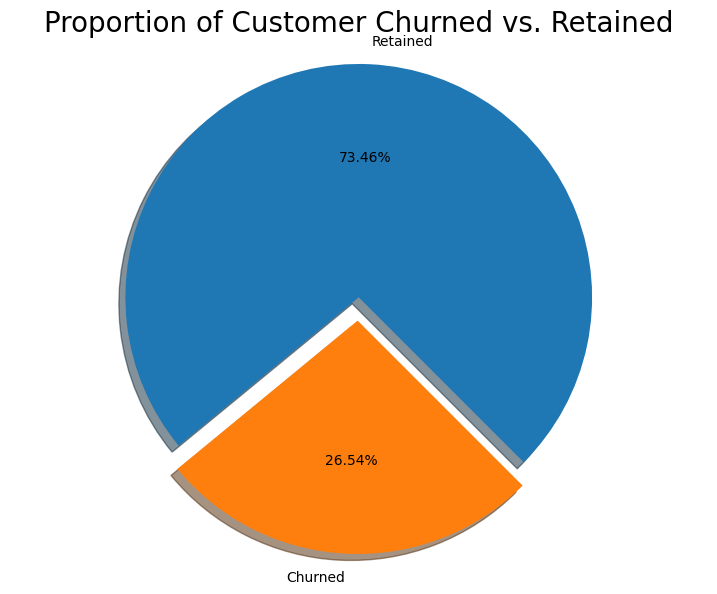

In [24]:
target_column = 'Churn'

labels = [
    'Retained',
    'Churned'
]

sizes = [
    dataset[target_column][dataset[target_column]=="No"].count(), # Retained
    dataset[target_column][dataset[target_column]=="Yes"].count() # Churned
]

explode = (0, 0.1)
fig, ax = plt.subplots(figsize=(9, 7))
ax.pie(
    x=sizes,
    explode=explode,
    labels=labels,
    autopct='%1.2f%%',
    shadow=True,
    startangle=-45
)

ax.axis('equal')
plt.title("Proportion of Customer Churned vs. Retained", size=20)
plt.show()

What happen here?

Answer:

Dataset ini sedikit tidak seimbang (imbalanced dataset), karena jumlah pelanggan yang tidak churn jauh lebih banyak daripada yang churn.
Jika kita menggunakan data ini untuk machine learning, model bisa cenderung bias terhadap kelas mayoritas ("No")/Retained.

# 5.&nbsp;Clean the Dataset

In [25]:
dataset["TotalCharges"]

,TotalCharges
0,29.85
1,1889.5
2,108.15
3,1840.75
4,151.65
...,...
7038,1990.5
7039,7362.9
7040,346.45
7041,306.6


In [26]:
# Clean the Dataset
dataset["TotalCharges"] = pd.to_numeric(
    dataset["TotalCharges"],
    errors='coerce'
)

dataset["TotalCharges"] = dataset["TotalCharges"].astype("float")

In [27]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [28]:
dataset.isna().any()

,0
customerID,False
gender,False
SeniorCitizen,False
Partner,False
Dependents,False
tenure,False
PhoneService,False
MultipleLines,False
InternetService,False
OnlineSecurity,False


In [29]:
dataset.isna().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [30]:
missing_value_mask = dataset["TotalCharges"].isna()
dataset[missing_value_mask]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,No,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,NaN,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,NaN,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,Yes,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,NaN,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,NaN,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,Yes,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,NaN,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,NaN,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,NaN,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,NaN,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,NaN,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,Yes,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,NaN,No


In [31]:
dataset.isna().any()

,0
customerID,False
gender,False
SeniorCitizen,False
Partner,False
Dependents,False
tenure,False
PhoneService,False
MultipleLines,False
InternetService,False
OnlineSecurity,False


In [32]:
# Take care of missing data
# Find the mean/median (if numerical) or mode (if categorical) and fill missing values of each columns programmatically.

# median: if the data distrbution is skewed
# mean: if the data distribution looks like normal distribution

# Identify columns with missing values
na_cols = dataset.columns[dataset.isna().any()].tolist()

# Iterate through columns with missing values
for col in na_cols:
    if pd.api.types.is_numeric_dtype(dataset[col]):
        # Fill numeric columns with the median/mean
        dataset[col] = dataset[col].fillna(dataset[col].median())
    else:
        # Fill non-numeric columns with the mode
        dataset[col] = dataset[col].fillna(dataset[col].mode()[0])

In [33]:
dataset.isna().any()

,0
customerID,False
gender,False
SeniorCitizen,False
Partner,False
Dependents,False
tenure,False
PhoneService,False
MultipleLines,False
InternetService,False
OnlineSecurity,False


# 6.&nbsp;Label Encode Binary Data

In [34]:
# binary_cols = []

# for col in dataset.columns[1:]:
#     if (dataset[col].dtype == 'object') and len(dataset[col].unique()) <= 2:
#         binary_cols.append(col)

In [35]:
# Label Encode Binary data

# Create a LabelEncoder object
le = LabelEncoder()

# Identify columns with 2 or fewer unique values and are of object type
binary_cols = [col for col in dataset.columns[1:] if dataset[col].dtype == 'object' and len(dataset[col].unique()) <= 2]

# Label encode the identified columns
for col in binary_cols:
    dataset[col] = le.fit_transform(dataset[col])

print(f"{len(binary_cols)} columns were label encoded.")

6 columns were label encoded.


In [36]:
dataset.head(5)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,0,0,1,0,1,0,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,1,Electronic check,29.85,29.85,0
1,5575-GNVDE,1,0,0,0,34,1,No,DSL,Yes,No,Yes,No,No,No,One year,0,Mailed check,56.95,1889.50,0
2,3668-QPYBK,1,0,0,0,2,1,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,1,Mailed check,53.85,108.15,1
3,7795-CFOCW,1,0,0,0,45,0,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,0,Bank transfer (automatic),42.30,1840.75,0
4,9237-HQITU,0,0,0,0,2,1,No,Fiber optic,No,No,No,No,No,No,Month-to-month,1,Electronic check,70.70,151.65,1


In [37]:
dataset['MultipleLines'].value_counts(normalize=True)

,proportion
MultipleLines,
No,0.481329
Yes,0.421837
No phone service,0.096834


In [38]:
dataset['PaymentMethod'].value_counts(normalize=True)

,proportion
PaymentMethod,
Electronic check,0.335794
Mailed check,0.228880
Bank transfer (automatic),0.219225
Credit card (automatic),0.216101


# 7.&nbsp;Exploratory Data Analysis

In [39]:
binary_cols

['gender',
 'Partner',
 'Dependents',
 'PhoneService',
 'PaperlessBilling',
 'Churn']

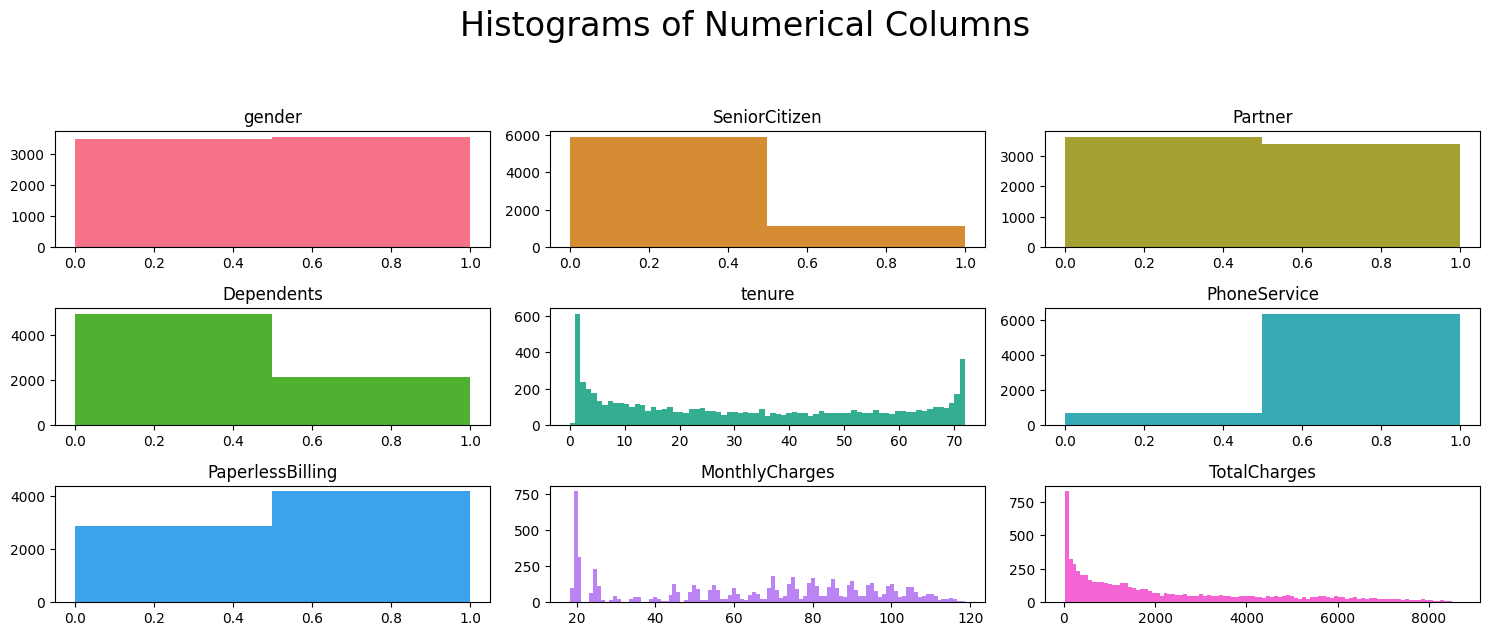

In [40]:
# Exploratory Data Analysis

# Plot Histogram of numeric columns
num_cols = [
    'gender',
    'SeniorCitizen',
    'Partner',
    'Dependents',
    'tenure',
    'PhoneService',
    'PaperlessBilling',
    'MonthlyCharges',
    'TotalCharges'
]

dataset2 = dataset[num_cols]

# Define a color palette with distinct colors
palette = sns.color_palette("husl", len(num_cols))

# Histogram:
fig = plt.figure(figsize=(15, 12))
plt.suptitle(
    'Histograms of Numerical Columns',
    horizontalalignment="center",
    fontstyle="normal",
    fontsize=24,
    fontfamily="sans-serif"
)

for i in range(dataset2.shape[1]):
    plt.subplot(6, 3, i + 1 )
    f = plt.gca()
    f.set_title(dataset2.columns.values[i])

    vals = np.size(dataset2.iloc[:, i].unique())
    if vals >= 100:
        vals = 100

    # Use the color palette for each subplot
    plt.hist(
        dataset2.iloc[:, i],
        bins=vals,
        color=palette[i]
    )

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

In [41]:
dataset['gender'].value_counts(normalize=True)

,proportion
gender,
1,0.504756
0,0.495244


In [42]:
dataset['SeniorCitizen'].value_counts(normalize=True)

,proportion
SeniorCitizen,
0,0.837853
1,0.162147


What are the insights from diagram above?


Answer:
1. Mayoritas pelanggan bukan senior dan tidak memiliki tanggungan.
2. Banyak pelanggan dengan tenure rendah, yang bisa terkait dengan churn.
3. Sebagian besar pelanggan menggunakan layanan telepon dan lebih memilih paperless billing.
4. Distribusi biaya bulanan bervariasi, tetapi banyak pelanggan berada di kisaran rendah hingga menengah.
5. Total biaya berlangganan meningkat seiring waktu, dengan lonjakan pelanggan baru.

In [43]:
dataset['Contract'].unique()

array(['Month-to-month', 'One year', 'Two year'], dtype=object)

## Analyze distribution of Key Categorical Variables

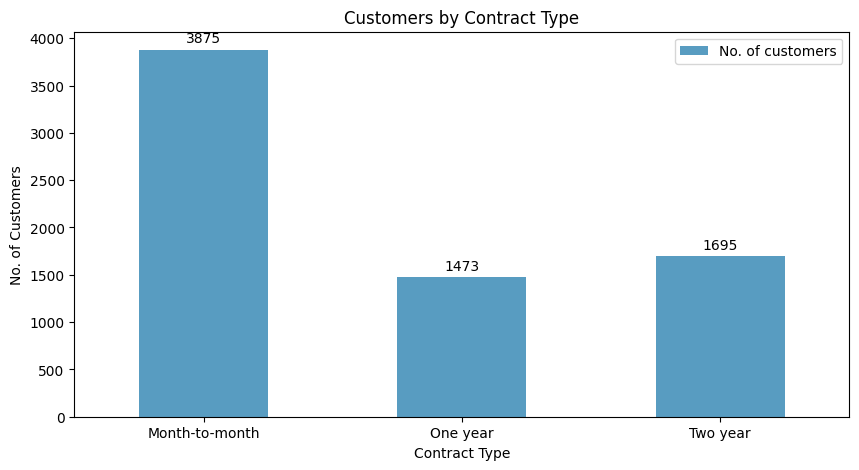

In [44]:
# Distribution of Contract Type
contract_split = dataset[[ "customerID", "Contract"]]
sectors = contract_split.groupby ("Contract")
contract_split = pd.DataFrame(sectors["customerID"].count())
contract_split.rename(
    columns={'customerID':'No. of customers'},
    inplace=True
)

ax = contract_split[["No. of customers"]].plot.bar(
    title='Customers by Contract Type',
    legend=True,
    table=False,
    grid=False,
    subplots=False,
    figsize=(10, 5),
    color='#589cc1',
    stacked=False
)

plt.ylabel(
    'No. of Customers',
    horizontalalignment="center",
    fontstyle="normal",
    fontfamily="sans-serif"
)
plt.xlabel(
    'Contract Type',
    horizontalalignment="center",
    fontstyle="normal",
    fontfamily="sans-serif"
)
plt.title(
    'Customers by Contract Type',
    horizontalalignment="center",
    fontstyle="normal",
    fontfamily="sans-serif"
)

plt.legend(loc='upper right')
plt.xticks(rotation=0, horizontalalignment="center")
plt.yticks(rotation=0, horizontalalignment="right")

x_labels = np.array(contract_split[["No. of customers"]])

def add_value_labels(ax, spacing=3):
    for rect in ax.patches:
        y_value = rect.get_height()
        x_value = rect.get_x() + rect.get_width() / 2
        space = spacing
        va = 'bottom'
        if y_value < 0:
            space *= -1
            va = 'top'
        label = "{:.0f}".format(y_value)
        ax.annotate(
            label,
            (x_value, y_value),
            xytext=(0, space),
            textcoords="offset points",
            ha='center',
            va=va)

add_value_labels(ax)

What can be derived from above diagram?

Answer:

1. Mayoritas pelanggan menggunakan kontrak bulanan (Month-to-month) dengan jumlah 3,875 pelanggan.
2. Pelanggan dengan kontrak satu tahun jauh lebih sedikit (1,473 pelanggan).
3. Pelanggan dengan kontrak dua tahun sedikit lebih banyak dibandingkan satu tahun, tetapi masih jauh lebih sedikit dibandingkan kontrak bulanan (1,695 pelanggan).




Perusahaan mungkin perlu mendorong lebih banyak pelanggan untuk memilih kontrak jangka panjang guna mengurangi churn.

Analisis churn berdasarkan jenis kontrak bisa dilakukan untuk melihat apakah pelanggan kontrak bulanan memiliki tingkat churn lebih tinggi dibandingkan pelanggan kontrak satu atau dua tahun.


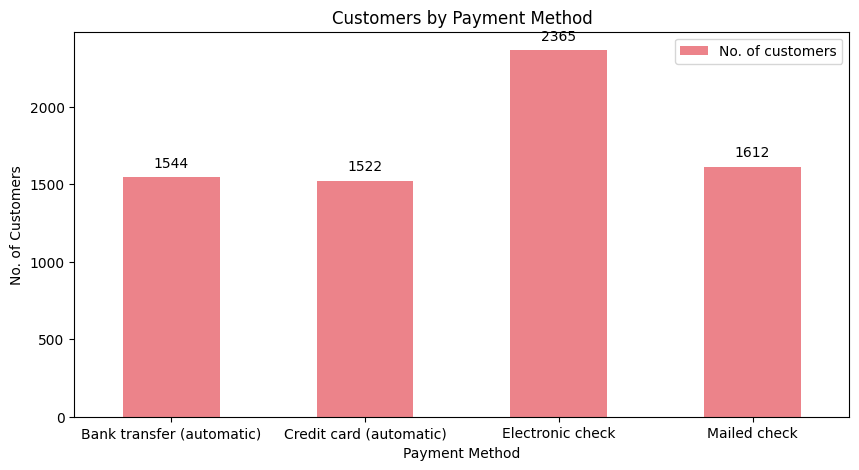

In [45]:
# Distribution of Payment Method Type

payment_method_split = dataset[[ "customerID", "PaymentMethod"]]
sectors = payment_method_split.groupby ("PaymentMethod")
payment_method_split = pd.DataFrame(sectors["customerID"].count())
payment_method_split.rename(
    columns={'customerID':'No. of customers'},
    inplace=True
)

ax = payment_method_split[["No. of customers"]].plot.bar(
    title='Customers by Payment Method',
    legend=True,
    table=False,
    grid=False,
    subplots=False,
    figsize=(10, 5),
    color='#ec838a',
    stacked=False
)

plt.ylabel(
    'No. of Customers',
    horizontalalignment="center",
    fontstyle="normal",
    fontfamily="sans-serif"
)
plt.xlabel(
    'Payment Method',
    horizontalalignment="center",
    fontstyle="normal",
    fontfamily="sans-serif"
)
plt.title(
    'Customers by Payment Method',
    horizontalalignment="center",
    fontstyle="normal",
    fontfamily="sans-serif"
)
plt.legend(loc='upper right')
plt.xticks(rotation=0, horizontalalignment="center")
plt.yticks(rotation=0, horizontalalignment="right")

x_labels = np.array(payment_method_split[["No. of customers"]])

def add_value_labels(ax, spacing=5):
    for rect in ax.patches:
        y_value = rect.get_height()
        x_value = rect.get_x() + rect.get_width() / 2
        space = spacing
        va = 'bottom'
        if y_value < 0:
            space *= -1
            va = 'top'
        label = "{:.0f}".format(y_value)
        ax.annotate(
            label,
            (x_value, y_value),
            xytext=(0, space),
            textcoords="offset points",
            ha='center',
            va=va)

add_value_labels(ax)

What can be derived from above diagram?

Answer:

1. Metode pembayaran yang paling banyak digunakan adalah "Electronic check", dengan 2,365 pelanggan.
2. Metode pembayaran otomatis seperti "Bank transfer (1,544 pelanggan)" dan "Credit card (1,522 pelanggan)" memiliki jumlah yang lebih rendah dibandingkan electronic check.
3. "Mailed check" digunakan oleh 1,612 pelanggan, sedikit lebih tinggi dibandingkan transfer bank dan kartu kredit otomatis.

Pelanggan yang menggunakan "Electronic check" mungkin memiliki tingkat churn lebih tinggi, karena pembayaran manual bisa lebih mudah dihentikan.

Perusahaan bisa mendorong pelanggan untuk beralih ke metode pembayaran otomatis guna meningkatkan retensi dan mengurangi churn.

Perlu dilakukan analisis lebih lanjut terkait hubungan antara metode pembayaran dan churn rate untuk memastikan apakah ada korelasi yang signifikan.

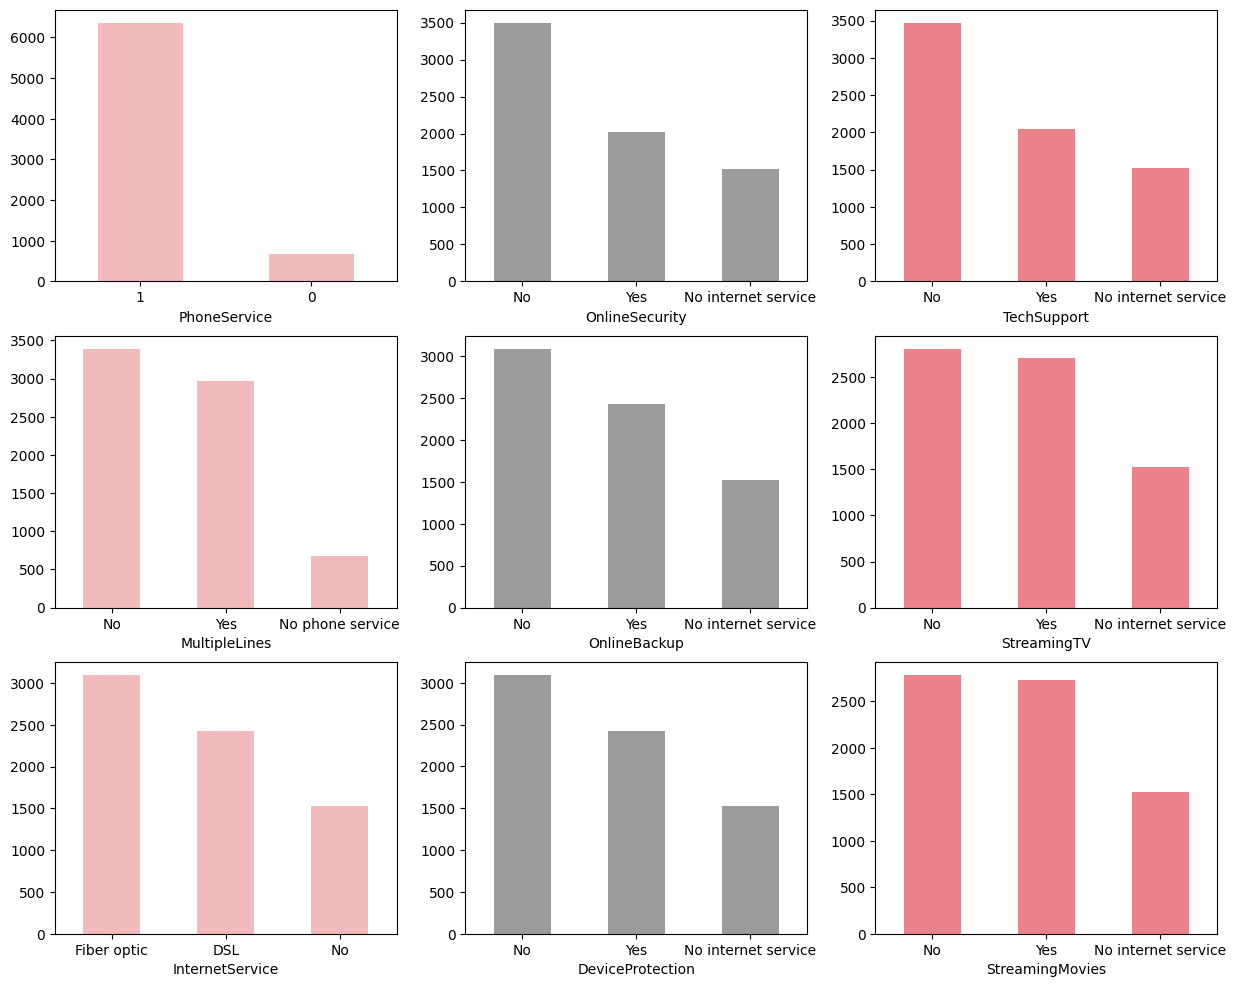

In [46]:
# Distribution of various Label Encoded Categorical Variables

services = [
    'PhoneService',
    'MultipleLines',
    'InternetService',
    'OnlineSecurity',
    'OnlineBackup',
    'DeviceProtection',
    'TechSupport',
    'StreamingTV',
    'StreamingMovies'
]

fig, axes = plt.subplots(
    nrows=3, ncols=3, figsize=(15,12)
)

for i, item in enumerate(services):
    if i < 3:
        ax = dataset[item].value_counts().plot(
            kind='bar', ax=axes[i, 0],
            rot=0, color='#f3babc'
        )

    elif i >= 3 and i < 6:
        ax = dataset[item].value_counts().plot(
            kind='bar', ax=axes[i-3, 1],
            rot=0, color ='#9b9c9a'
        )

    elif i < 9:
        ax = dataset[item].value_counts().plot(
            kind='bar', ax=axes[i-6, 2],
            rot=0, color='#ec838a'
        )

##  (TASK 1!) What are the insights from above diagrams?

Answer:

1. Layanan dasar seperti PhoneService umumnya sudah dimiliki oleh hampir semua pelanggan, jadi variansnya kecil.

2. Banyak pelanggan tidak menggunakan layanan tambahan seperti OnlineSecurity, OnlineBackup, DeviceProtection, dan TechSupport. Ini menunjukkan fitur tambahan tidak menjadi kebutuhan utama bagi sebagian besar user.

3. Layanan streaming seperti StreamingTV dan StreamingMovies juga menunjukkan pola yang mirip: ada kelompok yang menggunakan, tapi cukup banyak juga yang tidak memakai.

4. Secara keseluruhan, terlihat bahwa pelanggan lebih fokus ke layanan inti, sementara fitur tambahan bersifat opsional dan tidak merata digunakan.

## Analyze Churn Rate by Categorical variables

/tmp/ipykernel_3927/3239466703.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  churn_rate["churn_label"] = pd.Series(


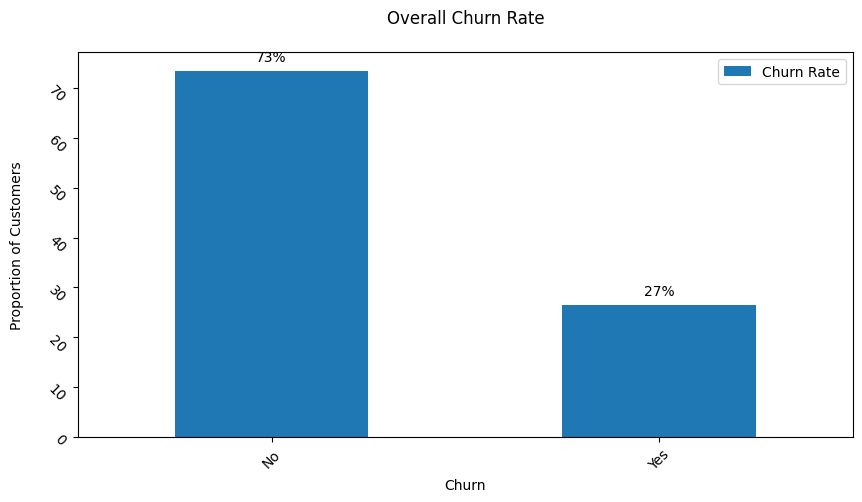

In [47]:
# Analyze Churn Rate by Categorical variables:

# Overall Churn Rate
import matplotlib.ticker as mtick
churn_rate = dataset[["Churn","customerID"]]
churn_rate["churn_label"] = pd.Series(
    np.where((churn_rate["Churn"] == 0), "No", "Yes")
)

sectors = churn_rate.groupby("churn_label")
churn_rate = pd.DataFrame(sectors["customerID"].count())
churn_rate["Churn Rate"] = (churn_rate["customerID"] / sum(churn_rate["customerID"])) * 100

ax = churn_rate[["Churn Rate"]].plot.bar(
    title="Overall Churn Rate",
    legend=True,
    table=False,
    grid=False,
    figsize=(10,5)
)

plt.ylabel(
    'Proportion of Customers\n',
    horizontalalignment="center",
    fontstyle="normal",
    fontfamily="sans-serif"
)
plt.xlabel(
    'Churn',
    horizontalalignment="center",
    fontstyle="normal",
    fontfamily="sans-serif"
)
plt.title(
    'Overall Churn Rate\n',
    horizontalalignment="center",
    fontstyle="normal",
    fontfamily="sans-serif"
)
plt.legend(loc='upper right')
plt.xticks(rotation=45, horizontalalignment="center")
plt.yticks(rotation=-45, horizontalalignment="right")

x_labels = np.array(churn_rate[["customerID"]])

def add_value_labels(ax, spacing=5):
    for rect in ax.patches:
        y_value = rect.get_height()
        x_value = rect.get_x() + rect.get_width() / 2
        space = spacing
        va = 'bottom'
        if y_value < 0:
            space *= -1
            va = 'top'
        label = "{:.0f}%".format(y_value)
        ax.annotate(
            label,
            (x_value, y_value),
            xytext=(0, space),
            textcoords="offset points",
            ha='center',
            va=va)

add_value_labels(ax)

In [48]:
dataset[['Contract', 'Churn']].value_counts()

Contract        Churn
Month-to-month  0        2220
                1        1655
Two year        0        1647
One year        0        1307
                1         166
Two year        1          48
Name: count, dtype: int64

In [49]:
dataset[['Contract', 'Churn']].value_counts(normalize=True)

Contract        Churn
Month-to-month  0        0.315207
                1        0.234985
Two year        0        0.233849
One year        0        0.185574
                1        0.023570
Two year        1        0.006815
Name: proportion, dtype: float64

In [50]:
dataset[['PaymentMethod', 'Churn']].value_counts(normalize=True).sort_index()

PaymentMethod              Churn
Bank transfer (automatic)  0        0.182593
                           1        0.036632
Credit card (automatic)    0        0.183161
                           1        0.032941
Electronic check           0        0.183729
                           1        0.152066
Mailed check               0        0.185148
                           1        0.043731
Name: proportion, dtype: float64

# 8.&nbsp;Encode Categorical Data

In [51]:
# In case if user_id is an object:
identity = dataset["customerID"]
dataset = dataset.drop(columns="customerID")

# convert rest of categorical variable into dummy
dataset = pd.get_dummies(
    dataset,
    dtype=int
)

# Rejoin userid to dataset (column concatenation)
dataset = pd.concat(
    [dataset, identity],
    axis=1
)

In [52]:
dataset

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,MultipleLines_No,MultipleLines_No phone service,MultipleLines_Yes,InternetService_DSL,InternetService_Fiber optic,InternetService_No,OnlineSecurity_No,OnlineSecurity_No internet service,OnlineSecurity_Yes,OnlineBackup_No,OnlineBackup_No internet service,OnlineBackup_Yes,DeviceProtection_No,DeviceProtection_No internet service,DeviceProtection_Yes,TechSupport_No,TechSupport_No internet service,TechSupport_Yes,StreamingTV_No,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_Month-to-month,Contract_One year,Contract_Two year,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,customerID
0,0,0,1,0,1,0,1,29.85,29.85,0,0,1,0,1,0,0,1,0,0,0,0,1,1,0,0,1,0,0,1,0,0,1,0,0,1,0,0,0,0,1,0,7590-VHVEG
1,1,0,0,0,34,1,0,56.95,1889.50,0,1,0,0,1,0,0,0,0,1,1,0,0,0,0,1,1,0,0,1,0,0,1,0,0,0,1,0,0,0,0,1,5575-GNVDE
2,1,0,0,0,2,1,1,53.85,108.15,1,1,0,0,1,0,0,0,0,1,0,0,1,1,0,0,1,0,0,1,0,0,1,0,0,1,0,0,0,0,0,1,3668-QPYBK
3,1,0,0,0,45,0,0,42.30,1840.75,0,0,1,0,1,0,0,0,0,1,1,0,0,0,0,1,0,0,1,1,0,0,1,0,0,0,1,0,1,0,0,0,7795-CFOCW
4,0,0,0,0,2,1,1,70.70,151.65,1,1,0,0,0,1,0,1,0,0,1,0,0,1,0,0,1,0,0,1,0,0,1,0,0,1,0,0,0,0,1,0,9237-HQITU
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,1,0,1,1,24,1,1,84.80,1990.50,0,0,0,1,1,0,0,0,0,1,1,0,0,0,0,1,0,0,1,0,0,1,0,0,1,0,1,0,0,0,0,1,6840-RESVB
7039,0,0,1,1,72,1,1,103.20,7362.90,0,0,0,1,0,1,0,1,0,0,0,0,1,0,0,1,1,0,0,0,0,1,0,0,1,0,1,0,0,1,0,0,2234-XADUH
7040,0,0,1,1,11,0,1,29.60,346.45,0,0,1,0,1,0,0,0,0,1,1,0,0,1,0,0,1,0,0,1,0,0,1,0,0,1,0,0,0,0,1,0,4801-JZAZL
7041,1,1,1,0,4,1,1,74.40,306.60,1,0,0,1,0,1,0,1,0,0,1,0,0,1,0,0,1,0,0,1,0,0,1,0,0,1,0,0,0,0,0,1,8361-LTMKD


# 9.&nbsp;Split Dataset into Dependent and Independent Variables

In [53]:
# identify response variable:
X = dataset.drop(columns="Churn")
y = dataset["Churn"]

# 10.&nbsp;Generate training and test datasets of dependent and independent variables


In [54]:
dataset["Churn"].value_counts(normalize=True)

,proportion
Churn,
0,0.73463
1,0.26537


In [55]:
#Step 12: Generate training and test datasets of dependent and independent variables

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    stratify=y,
    test_size=0.2, # use 0.1 if data is huge.
    random_state=42
)

# to resolve any class imbalance - use stratify parameter.

print("Number transactions X_train dataset: ", X_train.shape)
print("Number transactions y_train dataset: ", y_train.shape)
print("Number transactions X_test dataset: ", X_test.shape)
print("Number transactions y_test dataset: ", y_test.shape)

Number transactions X_train dataset:  (5634, 41)
Number transactions y_train dataset:  (5634,)
Number transactions X_test dataset:  (1409, 41)
Number transactions y_test dataset:  (1409,)


In [56]:
y_train.value_counts(normalize=True)

,proportion
Churn,
0,0.734647
1,0.265353


In [57]:
y_test.value_counts(normalize=True)

,proportion
Churn,
0,0.734564
1,0.265436


In [58]:
X_train

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,MultipleLines_No,MultipleLines_No phone service,MultipleLines_Yes,InternetService_DSL,InternetService_Fiber optic,InternetService_No,OnlineSecurity_No,OnlineSecurity_No internet service,OnlineSecurity_Yes,OnlineBackup_No,OnlineBackup_No internet service,OnlineBackup_Yes,DeviceProtection_No,DeviceProtection_No internet service,DeviceProtection_Yes,TechSupport_No,TechSupport_No internet service,TechSupport_Yes,StreamingTV_No,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_Month-to-month,Contract_One year,Contract_Two year,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,customerID
3738,1,0,0,0,35,0,0,49.20,1701.65,0,1,0,1,0,0,1,0,0,1,0,0,0,0,1,1,0,0,0,0,1,0,0,1,1,0,0,0,0,1,0,4950-BDEUX
3151,1,0,1,1,15,1,0,75.10,1151.55,1,0,0,0,1,0,0,0,1,1,0,0,1,0,0,1,0,0,1,0,0,1,0,0,1,0,0,0,0,0,1,7993-NQLJE
4860,1,0,1,1,13,0,0,40.55,590.35,0,1,0,1,0,0,0,0,1,0,0,1,1,0,0,0,0,1,1,0,0,1,0,0,0,0,1,0,0,0,1,7321-ZNSLA
3867,0,0,1,0,26,1,1,73.50,1905.70,1,0,0,1,0,0,1,0,0,0,0,1,0,0,1,1,0,0,0,0,1,0,0,1,0,0,1,0,1,0,0,4922-CVPDX
3810,1,0,1,1,1,1,0,44.55,44.55,1,0,0,1,0,0,1,0,0,1,0,0,1,0,0,1,0,0,1,0,0,1,0,0,1,0,0,0,0,1,0,2903-YYTBW
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6303,0,0,1,0,71,1,0,109.25,7707.70,0,0,1,0,1,0,1,0,0,0,0,1,0,0,1,0,0,1,0,0,1,0,0,1,0,0,1,0,0,1,0,6308-CQRBU
6227,1,0,0,0,2,1,0,46.05,80.35,1,0,0,1,0,0,1,0,0,1,0,0,1,0,0,1,0,0,1,0,0,1,0,0,1,0,0,1,0,0,0,2842-JTCCU
4673,0,1,0,0,25,1,1,102.80,2660.20,0,0,1,0,1,0,0,0,1,0,0,1,1,0,0,1,0,0,0,0,1,0,0,1,1,0,0,0,0,0,1,6402-ZFPPI
2710,0,0,1,0,24,1,0,20.40,482.80,1,0,0,0,0,1,0,1,0,0,1,0,0,1,0,0,1,0,0,1,0,0,1,0,0,1,0,0,1,0,0,3594-BDSOA


# 11.&nbsp;Removing Identifiers

In [59]:
# Step 13: Removing Identifiers
train_id = X_train["customerID"]
X_train = X_train.drop(columns=["customerID"])

test_id = X_test["customerID"]
X_test = X_test.drop(columns=["customerID"])

In [60]:
X_train

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,MultipleLines_No,MultipleLines_No phone service,MultipleLines_Yes,InternetService_DSL,InternetService_Fiber optic,InternetService_No,OnlineSecurity_No,OnlineSecurity_No internet service,OnlineSecurity_Yes,OnlineBackup_No,OnlineBackup_No internet service,OnlineBackup_Yes,DeviceProtection_No,DeviceProtection_No internet service,DeviceProtection_Yes,TechSupport_No,TechSupport_No internet service,TechSupport_Yes,StreamingTV_No,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_Month-to-month,Contract_One year,Contract_Two year,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
3738,1,0,0,0,35,0,0,49.20,1701.65,0,1,0,1,0,0,1,0,0,1,0,0,0,0,1,1,0,0,0,0,1,0,0,1,1,0,0,0,0,1,0
3151,1,0,1,1,15,1,0,75.10,1151.55,1,0,0,0,1,0,0,0,1,1,0,0,1,0,0,1,0,0,1,0,0,1,0,0,1,0,0,0,0,0,1
4860,1,0,1,1,13,0,0,40.55,590.35,0,1,0,1,0,0,0,0,1,0,0,1,1,0,0,0,0,1,1,0,0,1,0,0,0,0,1,0,0,0,1
3867,0,0,1,0,26,1,1,73.50,1905.70,1,0,0,1,0,0,1,0,0,0,0,1,0,0,1,1,0,0,0,0,1,0,0,1,0,0,1,0,1,0,0
3810,1,0,1,1,1,1,0,44.55,44.55,1,0,0,1,0,0,1,0,0,1,0,0,1,0,0,1,0,0,1,0,0,1,0,0,1,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6303,0,0,1,0,71,1,0,109.25,7707.70,0,0,1,0,1,0,1,0,0,0,0,1,0,0,1,0,0,1,0,0,1,0,0,1,0,0,1,0,0,1,0
6227,1,0,0,0,2,1,0,46.05,80.35,1,0,0,1,0,0,1,0,0,1,0,0,1,0,0,1,0,0,1,0,0,1,0,0,1,0,0,1,0,0,0
4673,0,1,0,0,25,1,1,102.80,2660.20,0,0,1,0,1,0,0,0,1,0,0,1,1,0,0,1,0,0,0,0,1,0,0,1,1,0,0,0,0,0,1
2710,0,0,1,0,24,1,0,20.40,482.80,1,0,0,0,0,1,0,1,0,0,1,0,0,1,0,0,1,0,0,1,0,0,1,0,0,1,0,0,1,0,0


# 12.&nbsp;Feature Scaling

In [61]:
# sc_X = StandardScaler()
# X_train2 = pd.DataFrame(sc_X.fit_transform(X_train))
# X_train2.columns = X_train.columns.values
# X_train2.index = X_train.index.values
# X_train = X_train2.copy()

# X_test2 = pd.DataFrame(sc_X.fit_transform(X_test))
# X_test2.columns = X_test.columns.values
# X_test2.index = X_test.index.values
# X_test = X_test2.copy()

In [62]:
# Train
sc_X = StandardScaler()
X_tr_columns = X_train.columns
X_tr_idx = X_train.index

X_train = pd.DataFrame(
    sc_X.fit_transform(X_train),
    columns=X_tr_columns,
    index=X_tr_idx
)


# Test
X_ts_columns = X_test.columns
X_ts_idx = X_test.index

X_test = pd.DataFrame(
    sc_X.transform(X_test),
    columns=X_ts_columns,
    index=X_ts_idx
)

In [63]:
X_train

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,MultipleLines_No,MultipleLines_No phone service,MultipleLines_Yes,InternetService_DSL,InternetService_Fiber optic,InternetService_No,OnlineSecurity_No,OnlineSecurity_No internet service,OnlineSecurity_Yes,OnlineBackup_No,OnlineBackup_No internet service,OnlineBackup_Yes,DeviceProtection_No,DeviceProtection_No internet service,DeviceProtection_Yes,TechSupport_No,TechSupport_No internet service,TechSupport_Yes,StreamingTV_No,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_Month-to-month,Contract_One year,Contract_Two year,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
3738,0.994336,-0.441773,-0.969234,-0.651557,0.102371,-3.013090,-1.202653,-0.521976,-0.263289,-0.95419,3.013090,-0.858338,1.381529,-0.887696,-0.524081,1.007125,-0.524081,-0.636111,1.143296,-0.524081,-0.735546,-0.884185,-0.524081,1.375572,1.016465,-0.524081,-0.643274,-0.808189,-0.524081,1.252163,-0.80549,-0.524081,1.247967,0.903464,-0.512782,-0.563822,-0.532326,-0.523806,1.406903,-0.543846
3151,0.994336,-0.441773,1.031742,1.534786,-0.711743,0.331885,-1.202653,0.337478,-0.504814,1.04801,-0.331885,-0.858338,-0.723836,1.126512,-0.524081,-0.992925,-0.524081,1.572053,1.143296,-0.524081,-0.735546,1.130985,-0.524081,-0.726971,1.016465,-0.524081,-0.643274,1.237335,-0.524081,-0.798618,1.24148,-0.524081,-0.801303,0.903464,-0.512782,-0.563822,-0.532326,-0.523806,-0.710781,1.838757
4860,0.994336,-0.441773,1.031742,1.534786,-0.793155,-3.013090,-1.202653,-0.809013,-0.751213,-0.95419,3.013090,-0.858338,1.381529,-0.887696,-0.524081,-0.992925,-0.524081,1.572053,-0.874664,-0.524081,1.359534,1.130985,-0.524081,-0.726971,-0.983802,-0.524081,1.554547,1.237335,-0.524081,-0.798618,1.24148,-0.524081,-0.801303,-1.106851,-0.512782,1.773611,-0.532326,-0.523806,-0.710781,1.838757
3867,-1.005696,-0.441773,1.031742,-0.651557,-0.263980,0.331885,0.831495,0.284384,-0.173699,1.04801,-0.331885,-0.858338,1.381529,-0.887696,-0.524081,1.007125,-0.524081,-0.636111,-0.874664,-0.524081,1.359534,-0.884185,-0.524081,1.375572,1.016465,-0.524081,-0.643274,-0.808189,-0.524081,1.252163,-0.80549,-0.524081,1.247967,-1.106851,-0.512782,1.773611,-0.532326,1.909105,-0.710781,-0.543846
3810,0.994336,-0.441773,1.031742,1.534786,-1.281624,0.331885,-1.202653,-0.676279,-0.990851,1.04801,-0.331885,-0.858338,1.381529,-0.887696,-0.524081,1.007125,-0.524081,-0.636111,1.143296,-0.524081,-0.735546,1.130985,-0.524081,-0.726971,1.016465,-0.524081,-0.643274,1.237335,-0.524081,-0.798618,1.24148,-0.524081,-0.801303,0.903464,-0.512782,-0.563822,-0.532326,-0.523806,1.406903,-0.543846
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6303,-1.005696,-0.441773,1.031742,-0.651557,1.567778,0.331885,-1.202653,1.470695,2.373711,-0.95419,-0.331885,1.165042,-0.723836,1.126512,-0.524081,1.007125,-0.524081,-0.636111,-0.874664,-0.524081,1.359534,-0.884185,-0.524081,1.375572,-0.983802,-0.524081,1.554547,-0.808189,-0.524081,1.252163,-0.80549,-0.524081,1.247967,-1.106851,-0.512782,1.773611,-0.532326,-0.523806,1.406903,-0.543846
6227,0.994336,-0.441773,-0.969234,-0.651557,-1.240918,0.331885,-1.202653,-0.626504,-0.975133,1.04801,-0.331885,-0.858338,1.381529,-0.887696,-0.524081,1.007125,-0.524081,-0.636111,1.143296,-0.524081,-0.735546,1.130985,-0.524081,-0.726971,1.016465,-0.524081,-0.643274,1.237335,-0.524081,-0.798618,1.24148,-0.524081,-0.801303,0.903464,-0.512782,-0.563822,1.878547,-0.523806,-0.710781,-0.543846
4673,-1.005696,2.263606,-0.969234,-0.651557,-0.304686,0.331885,0.831495,1.256662,0.157569,-0.95419,-0.331885,1.165042,-0.723836,1.126512,-0.524081,-0.992925,-0.524081,1.572053,-0.874664,-0.524081,1.359534,1.130985,-0.524081,-0.726971,1.016465,-0.524081,-0.64

In [64]:
dataset.describe()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,MultipleLines_No,MultipleLines_No phone service,MultipleLines_Yes,InternetService_DSL,InternetService_Fiber optic,InternetService_No,OnlineSecurity_No,OnlineSecurity_No internet service,OnlineSecurity_Yes,OnlineBackup_No,OnlineBackup_No internet service,OnlineBackup_Yes,DeviceProtection_No,DeviceProtection_No internet service,DeviceProtection_Yes,TechSupport_No,TechSupport_No internet service,TechSupport_Yes,StreamingTV_No,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_Month-to-month,Contract_One year,Contract_Two year,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
count,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.504756,0.162147,0.483033,0.299588,32.371149,0.903166,0.592219,64.761692,2281.916928,0.265370,0.481329,0.096834,0.421837,0.343746,0.439585,0.216669,0.496663,0.216669,0.286668,0.438450,0.216669,0.344881,0.439443,0.216669,0.343888,0.493114,0.216669,0.290217,0.398978,0.216669,0.384353,0.395428,0.216669,0.387903,0.550192,0.209144,0.240664,0.219225,0.216101,0.335794,0.228880
std,0.500013,0.368612,0.499748,0.458110,24.559481,0.295752,0.491457,30.090047,2265.270398,0.441561,0.499687,0.295752,0.493888,0.474991,0.496372,0.412004,0.500024,0.412004,0.452237,0.496232,0.412004,0.475363,0.496355,0.412004,0.475038,0.499988,0.412004,0.453895,0.489723,0.412004,0.486477,0.488977,0.412004,0.487307,0.497510,0.406726,0.427517,0.413751,0.411613,0.472301,0.420141
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,18.250000,18.800000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,9.000000,1.000000,0.000000,35.500000,402.225000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,1.000000,0.000000,0.000000,0.000000,29.000000,1.000000,1.000000,70.350000,1397.475000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,1.000000,0.000000,1.000000,1.000000,55.000000,1.000000,1.000000,89.850000,3786.600000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,0.000000,1.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
max,1.000000,1.000000,1.000000,1.000000,72.000000,1.000000,1.000000,118.750000,8684.800000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [65]:
X_train.describe()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,MultipleLines_No,MultipleLines_No phone service,MultipleLines_Yes,InternetService_DSL,InternetService_Fiber optic,InternetService_No,OnlineSecurity_No,OnlineSecurity_No internet service,OnlineSecurity_Yes,OnlineBackup_No,OnlineBackup_No internet service,OnlineBackup_Yes,DeviceProtection_No,DeviceProtection_No internet service,DeviceProtection_Yes,TechSupport_No,TechSupport_No internet service,TechSupport_Yes,StreamingTV_No,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_Month-to-month,Contract_One year,Contract_Two year,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
count,5.634000e+03,5.634000e+03,5.634000e+03,5.634000e+03,5.634000e+03,5.634000e+03,5.634000e+03,5.634000e+03,5.634000e+03,5.634000e+03,5.634000e+03,5.634000e+03,5.634000e+03,5.634000e+03,5.634000e+03,5.634000e+03,5.634000e+03,5.634000e+03,5.634000e+03,5.634000e+03,5.634000e+03,5.634000e+03,5.634000e+03,5.634000e+03,5.634000e+03,5.634000e+03,5.634000e+03,5.634000e+03,5.634000e+03,5.634000e+03,5.634000e+03,5.634000e+03,5.634000e+03,5.634000e+03,5.634000e+03,5.634000e+03,5.634000e+03,5.634000e+03,5.634000e+03,5.634000e+03
mean,1.135052e-16,7.440898e-17,-7.031018e-17,2.900689e-17,-1.008935e-17,-2.679985e-18,3.941154e-17,-2.402527e-16,-3.783508e-18,1.135052e-17,2.679985e-18,-2.522338e-18,7.314781e-17,-4.287975e-17,-7.724661e-17,5.801378e-17,-7.724661e-17,2.143988e-17,4.666326e-17,-7.724661e-17,2.774572e-17,-1.034159e-16,-7.724661e-17,3.783508e-18,-8.954301e-17,-7.724661e-17,-2.017871e-17,7.314781e-17,-7.724661e-17,8.828185e-18,-1.122441e-16,-7.724661e-17,5.927495e-17,3.531274e-17,-4.540209e-17,4.760914e-17,2.522338e-17,-4.287975e-17,-3.279040e-17,-2.017871e-17
std,1.000089e+00,1.000089e+00,1.000089e+00,1.000089e+00,1.000089e+00,1.000089e+00,1.000089e+00,1.000089e+00,1.000089e+00,1.000089e+00,1.000089e+00,1.000089e+00,1.000089e+00,1.000089e+00,1.000089e+00,1.000089e+00,1.000089e+00,1.000089e+00,1.000089e+00,1.000089e+00,1.000089e+00,1.000089e+00,1.000089e+00,1.000089e+00,1.000089e+00,1.000089e+00,1.000089e+00,1.000089e+00,1.000089e+00,1.000089e+00,1.000089e+00,1.000089e+00,1.000089e+00,1.000089e+00,1.000089e+00,1.000089e+00,1.000089e+00,1.000089e+00,1.000089e+00,1.000089e+00
min,-1.005696e+00,-4.417730e-01,-9.692341e-01,-6.515565e-01,-1.322329e+00,-3.013090e+00,-1.202653e+00,-1.544028e+00,-1.002135e+00,-9.541898e-01,-3.318852e-01,-8.583384e-01,-7.238358e-01,-8.876958e-01,-5.240808e-01,-9.929253e-01,-5.240808e-01,-6.361110e-01,-8.746643e-01,-5.240808e-01,-7.355464e-01,-8.841853e-01,-5.240808e-01,-7.269705e-01,-9.838017e-01,-5.240808e-01,-6.432742e-01,-8.081887e-01,-5.240808e-01,-7.986180e-01,-8.054904e-01,-5.240808e-01,-8.013032e-01,-1.106851e+00,-5.127821e-01,-5.638215e-01,-5.323263e-01,-5.238056e-01,-7.107811e-01,-5.438457e-01
25%,-1.005696e+00,-4.417730e-01,-9.692341e-01,-6.515565e-01,-9.559779e-01,3.318852e-01,-1.202653e+00,-9.711977e-01,-8.309023e-01,-9.541898e-01,-3.318852e-01,-8.583384e-01,-7.238358e-01,-8.876958e-01,-5.240808e-01,-9.929253e-01,-5.240808e-01,-6.361110e-01,-8.746643e-01,-5.240808e-01,-7.355464e-01,-8.841853e-01,-5.240808e-01,-7.269705e-01,-9.838017e-01,-5.240808e-01,-6.432742e-01,-8.081887e-01,-5.240808e-01,-7.986180e-01,-8.054904e-01,-5.240808e-01,-8.013032e-01,-1.106851e+00,-5.127821e-01,-5.638215e-01,-5.323263e-01,-5.238056e-01,-7.107811e-01,-5.438457e-01
50%,9.943362e-01,-4.417730e-01,-9.692341e-01,-6.515565e-01,-1.418632e-01,3.318852e-01,8.314950e-01,1.848336e-01,-3.968393e-01,-9.541898e-01,-3.318852e-01,-8.583384e-01,-7.238358e-01,-8.876958e-01,-5.240808e-01,-9.929253e-01,-5.240808e-01,-6.361110e-01,-8.746643e-01,-5.240808e-01,-7.355464e-01,-8.841853e-01,-5.240808e-01,-7.269705e-01,-9.838017e-01,-5.240808e-01,-6.432742e-01,-8.081887e-01,-5.240808e-01,-7.986180e-01,-8.0

# 13.&nbsp;Model Selection

In [66]:
# Compare Baseline Classification Algorithms - First Iteration
# Using Accuracy and ROC AUC Mean Metrics

models = []

models.append(
    (
        'Logistic Regression',
        LogisticRegression(
            solver='liblinear',
            random_state=42,
            class_weight='balanced'
        )
    )
)

# Other models
models.append(
    (
        'Random Forest',
        RandomForestClassifier(
            n_estimators=100,
            criterion='entropy',
            random_state=42
        )
    )
)

# Tambahkan model lain

# Evaluating Model Results:
acc_results = []
auc_results = []
names = []

# set table to populate with perfo, performance result
col = ['Algorithm', 'ROC AUC Mean', 'ROC AUC STD', 'Accuracy Mean', 'Accuracy STD']
model_results = pd.DataFrame(columns = col)

#Evaluate model
i = 0
for name, model in models:
    kfold = KFold(n_splits = 10) # 10 Cross validation
    cv_acc_results = cross_val_score(model, X_train, y_train, cv=kfold, scoring='accuracy')
    cv_auc_results = cross_val_score(model, X_train, y_train, cv=kfold, scoring='roc_auc')
    acc_results.append(cv_acc_results)
    auc_results.append(cv_auc_results)
    names.append(name)
    model_results.loc[i] =[
        name,
        round(cv_auc_results.mean() * 100, 2),
        round(cv_auc_results.std() * 100, 2),
        round(cv_acc_results.mean() * 100, 2),
        round(cv_acc_results.std() * 100, 2)
    ]
    i += 1

model_results.sort_values(
    by=['ROC AUC Mean'],
    ascending = False
)

,Algorithm,ROC AUC Mean,ROC AUC STD,Accuracy Mean,Accuracy STD
0,Logistic Regression,84.52,1.73,74.90,2.41
1,Random Forest,82.11,1.76,78.43,1.41


In [67]:
models

[('Logistic Regression',
  LogisticRegression(class_weight='balanced', random_state=42, solver='liblinear')),
 ('Random Forest',
  RandomForestClassifier(criterion='entropy', random_state=42))]

# 14.&nbsp; (TASK 2!) Coding Homework
Do the exact same modeling process, but with preprocessing: **handling imbalance data!**

## Generate training and test datasets of dependent and independent variables


In [69]:
# Generate training and test datasets of dependent and independent variables
# Task 2 dimulai dari dataset yang sudah dibersihkan, binary encoded, dan one-hot encoded.

target_col = "Churn"

X_task2 = dataset.drop(columns=target_col)
y_task2 = dataset[target_col].copy()

# Alias agar sesuai dengan template soal.
response = y_task2.copy()

X_train_task2, X_test_task2, y_train_task2, y_test_task2 = train_test_split(
    X_task2,
    y_task2,
    stratify=y_task2,
    test_size=0.2,
    random_state=42
)

print("Number transactions X_train dataset:", X_train_task2.shape)
print("Number transactions y_train dataset:", y_train_task2.shape)
print("Number transactions X_test dataset :", X_test_task2.shape)
print("Number transactions y_test dataset :", y_test_task2.shape)


Number transactions X_train dataset: (5634, 41)
Number transactions y_train dataset: (5634,)
Number transactions X_test dataset : (1409, 41)
Number transactions y_test dataset : (1409,)


In [70]:
print("Raw Data Target Percentage")

target_distribution = (
    response.value_counts(normalize=True)
    .sort_index()
    .mul(100)
    .round(2)
)

print("Not Churn (0): {}%".format(target_distribution.get(0, 0)))
print("Churn (1)    : {}%".format(target_distribution.get(1, 0)))

print("\nTraining Target Percentage")
print((y_train_task2.value_counts(normalize=True).sort_index() * 100).round(2))

print("\nTesting Target Percentage")
print((y_test_task2.value_counts(normalize=True).sort_index() * 100).round(2))


Raw Data Target Percentage
Not Churn (0): 73.46%
Churn (1)    : 26.54%

Training Target Percentage
Churn
0    73.46
1    26.54
Name: proportion, dtype: float64

Testing Target Percentage
Churn
0    73.46
1    26.54
Name: proportion, dtype: float64


In [71]:
# Removing Identifiers
# customerID tidak digunakan sebagai fitur karena hanya berfungsi sebagai identitas unik pelanggan.

if "customerID" in X_train_task2.columns:
    train_id_task2 = X_train_task2["customerID"].copy()
    X_train_task2 = X_train_task2.drop(columns=["customerID"])

if "customerID" in X_test_task2.columns:
    test_id_task2 = X_test_task2["customerID"].copy()
    X_test_task2 = X_test_task2.drop(columns=["customerID"])

print("Train columns after removing identifier:", X_train_task2.shape[1])
print("Test columns after removing identifier :", X_test_task2.shape[1])


Train columns after removing identifier: 40
Test columns after removing identifier : 40


## Feature Scaling

In [72]:
# Step 14: Feature Scaling
# Scaling dilakukan sebelum SMOTE karena SMOTE memakai jarak antar data.

sc_X_task2 = StandardScaler()

X_train_task2_scaled = pd.DataFrame(
    sc_X_task2.fit_transform(X_train_task2),
    columns=X_train_task2.columns,
    index=X_train_task2.index
)

X_test_task2_scaled = pd.DataFrame(
    sc_X_task2.transform(X_test_task2),
    columns=X_test_task2.columns,
    index=X_test_task2.index
)

display(X_train_task2_scaled.head())


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,MultipleLines_No,MultipleLines_No phone service,MultipleLines_Yes,InternetService_DSL,InternetService_Fiber optic,InternetService_No,OnlineSecurity_No,OnlineSecurity_No internet service,OnlineSecurity_Yes,OnlineBackup_No,OnlineBackup_No internet service,OnlineBackup_Yes,DeviceProtection_No,DeviceProtection_No internet service,DeviceProtection_Yes,TechSupport_No,TechSupport_No internet service,TechSupport_Yes,StreamingTV_No,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_Month-to-month,Contract_One year,Contract_Two year,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
3738,0.994336,-0.441773,-0.969234,-0.651557,0.102371,-3.013090,-1.202653,-0.521976,-0.263289,-0.95419,3.013090,-0.858338,1.381529,-0.887696,-0.524081,1.007125,-0.524081,-0.636111,1.143296,-0.524081,-0.735546,-0.884185,-0.524081,1.375572,1.016465,-0.524081,-0.643274,-0.808189,-0.524081,1.252163,-0.80549,-0.524081,1.247967,0.903464,-0.512782,-0.563822,-0.532326,-0.523806,1.406903,-0.543846
3151,0.994336,-0.441773,1.031742,1.534786,-0.711743,0.331885,-1.202653,0.337478,-0.504814,1.04801,-0.331885,-0.858338,-0.723836,1.126512,-0.524081,-0.992925,-0.524081,1.572053,1.143296,-0.524081,-0.735546,1.130985,-0.524081,-0.726971,1.016465,-0.524081,-0.643274,1.237335,-0.524081,-0.798618,1.24148,-0.524081,-0.801303,0.903464,-0.512782,-0.563822,-0.532326,-0.523806,-0.710781,1.838757
4860,0.994336,-0.441773,1.031742,1.534786,-0.793155,-3.013090,-1.202653,-0.809013,-0.751213,-0.95419,3.013090,-0.858338,1.381529,-0.887696,-0.524081,-0.992925,-0.524081,1.572053,-0.874664,-0.524081,1.359534,1.130985,-0.524081,-0.726971,-0.983802,-0.524081,1.554547,1.237335,-0.524081,-0.798618,1.24148,-0.524081,-0.801303,-1.106851,-0.512782,1.773611,-0.532326,-0.523806,-0.710781,1.838757
3867,-1.005696,-0.441773,1.031742,-0.651557,-0.263980,0.331885,0.831495,0.284384,-0.173699,1.04801,-0.331885,-0.858338,1.381529,-0.887696,-0.524081,1.007125,-0.524081,-0.636111,-0.874664,-0.524081,1.359534,-0.884185,-0.524081,1.375572,1.016465,-0.524081,-0.643274,-0.808189,-0.524081,1.252163,-0.80549,-0.524081,1.247967,-1.106851,-0.512782,1.773611,-0.532326,1.909105,-0.710781,-0.543846
3810,0.994336,-0.441773,1.031742,1.534786,-1.281624,0.331885,-1.202653,-0.676279,-0.990851,1.04801,-0.331885,-0.858338,1.381529,-0.887696,-0.524081,1.007125,-0.524081,-0.636111,1.143296,-0.524081,-0.735546,1.130985,-0.524081,-0.726971,1.016465,-0.524081,-0.643274,1.237335,-0.524081,-0.798618,1.24148,-0.524081,-0.801303,0.903464,-0.512782,-0.563822,-0.532326,-0.523806,1.406903,-0.543846


## Model Selection

### Compare Baseline Classification Algorithms

In [74]:
# Compare Baseline Classification Algorithms - First Iteration
# Using Accuracy and ROC AUC Mean Metrics
# Data masih imbalanced. Tahap ini menjadi pembanding sebelum oversampling.

from sklearn.metrics import roc_auc_score
from sklearn.model_selection import StratifiedKFold

models_task2 = []

models_task2.append(
    (
        "Logistic Regression",
        LogisticRegression(
            solver="liblinear",
            random_state=42
        )
    )
)

models_task2.append(
    (
        "Decision Tree",
        DecisionTreeClassifier(
            criterion="entropy",
            random_state=42
        )
    )
)

models_task2.append(
    (
        "Random Forest",
        RandomForestClassifier(
            n_estimators=100,
            criterion="entropy",
            random_state=42
        )
    )
)

# Evaluating Model Results:
acc_results = []
auc_results = []
names = []

# set table to table to populate with performance results
col = ["Algorithm", "ROC AUC Mean", "ROC AUC STD", "Accuracy Mean", "Accuracy STD"]
model_results = pd.DataFrame(columns=col)

# evaluate each model using k-fold cross-validation
skfold = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

i = 0
for name, model in models_task2:
    cv_acc_results = cross_val_score(
        model,
        X_train_task2_scaled,
        y_train_task2,
        cv=skfold,
        scoring="accuracy"
    )

    cv_auc_results = cross_val_score(
        model,
        X_train_task2_scaled,
        y_train_task2,
        cv=skfold,
        scoring="roc_auc"
    )

    acc_results.append(cv_acc_results)
    auc_results.append(cv_auc_results)
    names.append(name)

    model_results.loc[i] = [
        name,
        round(cv_auc_results.mean() * 100, 2),
        round(cv_auc_results.std() * 100, 2),
        round(cv_acc_results.mean() * 100, 2),
        round(cv_acc_results.std() * 100, 2)
    ]

    i += 1

model_results = model_results.sort_values(
    by=["ROC AUC Mean"],
    ascending=False
).reset_index(drop=True)

display(model_results)


,Algorithm,ROC AUC Mean,ROC AUC STD,Accuracy Mean,Accuracy STD
0,Logistic Regression,84.59,1.47,80.19,1.32
1,Random Forest,82.27,1.41,78.83,1.17
2,Decision Tree,66.38,1.63,73.48,1.54


### Visualize Classification Algorithms Accuracy Comparisons

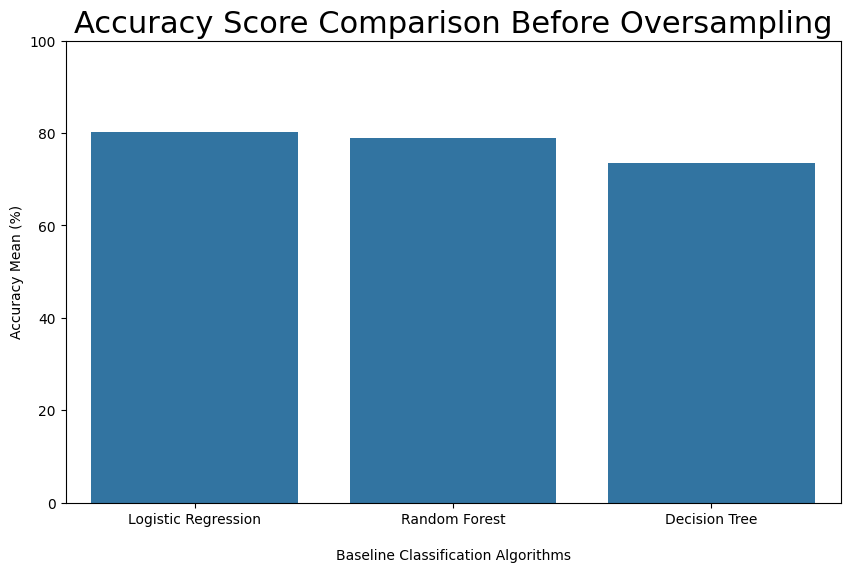

In [75]:
# Visualize Classification Algorithms Accuracy Comparisons:


# Using Accuracy Mean:

plt.figure(figsize=(10, 6))
sns.barplot(
    data=model_results,
    x="Algorithm",
    y="Accuracy Mean"
)

plt.title(
    "Accuracy Score Comparison Before Oversampling",
    horizontalalignment="center",
    fontstyle="normal",
    fontsize=22,
    fontfamily="sans-serif"
)
plt.xlabel("\nBaseline Classification Algorithms")
plt.ylabel("Accuracy Mean (%)")
plt.xticks(rotation=0, horizontalalignment="center")
plt.yticks(rotation=0, horizontalalignment="right")
plt.ylim(0, 100)
plt.show()

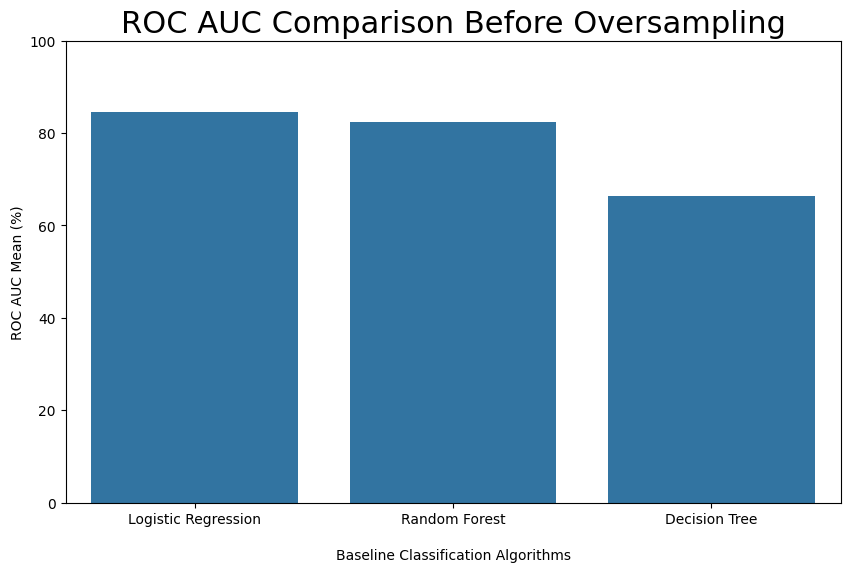

In [76]:
# using Area under ROC Curve:

plt.figure(figsize=(10, 6))
sns.barplot(
    data=model_results,
    x="Algorithm",
    y="ROC AUC Mean"
)

plt.title(
    "ROC AUC Comparison Before Oversampling",
    horizontalalignment="center",
    fontstyle="normal",
    fontsize=22,
    fontfamily="sans-serif"
)
plt.xlabel("\nBaseline Classification Algorithms")
plt.ylabel("ROC AUC Mean (%)")
plt.xticks(rotation=0, horizontalalignment="center")
plt.yticks(rotation=0, horizontalalignment="right")
plt.ylim(0, 100)
plt.show()

### SMOTE Oversampling

Tahap oversampling ini dilakukan pada tahap setelah data split dan cross validation ROC_AUC Scoring. Lalu hanya diaplikasikan hanya pada training set. Hal tersebut dikarenakan kalau dilakukan pada tahap sebelum splitting dan Cross_validation maka akan merubah hasil validation menjadi 50: 50 sementara seharusnya yaitu sekitar 74 : 26.

In [77]:
# Handling imbalance dengan SMOTE Oversampling
# SMOTE hanya diterapkan pada training set agar test set tetap merepresentasikan data asli.

try:
    from imblearn.over_sampling import SMOTE
except ModuleNotFoundError:
    import sys
    import subprocess
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "imbalanced-learn"])
    from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train_task2_scaled,
    y_train_task2
)

print("Before SMOTE")
print(y_train_task2.value_counts().sort_index())

print("\nAfter SMOTE")
print(pd.Series(y_train_smote).value_counts().sort_index())

imbalance_comparison = pd.DataFrame({
    "Before SMOTE": y_train_task2.value_counts().sort_index(),
    "After SMOTE": pd.Series(y_train_smote).value_counts().sort_index()
})

imbalance_comparison.index = ["Not Churn (0)", "Churn (1)"]
display(imbalance_comparison)

Before SMOTE
Churn
0    4139
1    1495
Name: count, dtype: int64

After SMOTE
Churn
0    4139
1    4139
Name: count, dtype: int64


,Before SMOTE,After SMOTE
Not Churn (0),4139,4139
Churn (1),1495,4139


### Searching Optimum Number of Trees for Random Forest Model

In [78]:
# Searching Optimum Number of Trees for Random Forest Model
# Pencarian dilakukan pada training set yang sudah di-oversampling.

n_estimators_list = [50, 100, 150, 200, 300, 500]
rf_tree_results = []

for n_tree in n_estimators_list:
    rf_model = RandomForestClassifier(
        n_estimators=n_tree,
        criterion="entropy",
        random_state=42,
        n_jobs=-1
    )

    rf_auc_score = cross_val_score(
        rf_model,
        X_train_smote,
        y_train_smote,
        cv=skfold,
        scoring="roc_auc"
    )

    rf_tree_results.append({
        "n_estimators": n_tree,
        "ROC AUC Mean": round(rf_auc_score.mean() * 100, 2),
        "ROC AUC STD": round(rf_auc_score.std() * 100, 2)
    })

rf_tree_results = pd.DataFrame(rf_tree_results)

best_n_trees = int(
    rf_tree_results.sort_values(
        by="ROC AUC Mean",
        ascending=False
    ).iloc[0]["n_estimators"]
)

print("Best number of trees:", best_n_trees)
display(rf_tree_results)

Best number of trees: 500


,n_estimators,ROC AUC Mean,ROC AUC STD
0,50,92.71,0.64
1,100,92.86,0.59
2,150,92.92,0.61
3,200,92.97,0.63
4,300,93.02,0.65
5,500,93.04,0.67


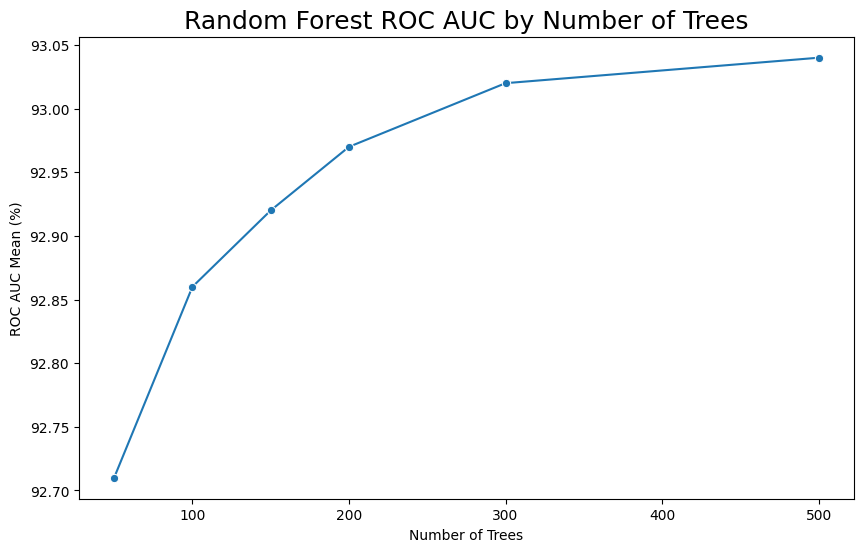

In [79]:
plt.figure(figsize=(10, 6))
sns.lineplot(
    data=rf_tree_results,
    x="n_estimators",
    y="ROC AUC Mean",
    marker="o"
)

plt.title("Random Forest ROC AUC by Number of Trees", fontsize=18)
plt.xlabel("Number of Trees")
plt.ylabel("ROC AUC Mean (%)")
plt.show()


### Compare Baseline Classification Algorithms

In [81]:
# Compare Baseline Classification Algorithms - Second Iteration
# Evaluasi dilakukan pada test set yang tidak di-oversampling.

def evaluate_classification_model(model, X_train_data, y_train_data, X_test_data, y_test_data):
    model.fit(X_train_data, y_train_data)

# Predicting the Test set results
    y_pred = model.predict(X_test_data)

    if hasattr(model, "predict_proba"):
        y_proba = model.predict_proba(X_test_data)[:, 1]
        auc_score = roc_auc_score(y_test_data, y_proba)
    else:
        y_proba = None
        auc_score = np.nan

    return {
        "ROC AUC": round(auc_score, 4),
        "Accuracy": round(accuracy_score(y_test_data, y_pred), 4),
        "Precision": round(precision_score(y_test_data, y_pred, zero_division=0), 4),
        "Recall": round(recall_score(y_test_data, y_pred, zero_division=0), 4),
        "F1 Score": round(f1_score(y_test_data, y_pred, zero_division=0), 4),
        "F2 Score": round(fbeta_score(y_test_data, y_pred, beta=2, zero_division=0), 4)
    }

# Logistic Regression--------------------------------------
# Decision Tree--------------------------------------------
# Random Forest--------------------------------------------
models_eval_task2 = {
    "Logistic Regression": LogisticRegression(
        solver="liblinear",
        random_state=42
    ),
    "Decision Tree": DecisionTreeClassifier(
        criterion="entropy",
        random_state=42
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=best_n_trees,
        criterion="entropy",
        random_state=42,
        n_jobs=-1
    )
}


#Evaluate results
results_before = []

for name, model in models_eval_task2.items():
    metrics = evaluate_classification_model(
        model,
        X_train_task2_scaled,
        y_train_task2,
        X_test_task2_scaled,
        y_test_task2
    )

    metrics["Algorithm"] = name
    results_before.append(metrics)

results = pd.DataFrame(results_before)[
    ["Algorithm", "ROC AUC", "Accuracy", "Precision", "Recall", "F1 Score", "F2 Score"]
]

results_smote = []

for name, model in models_eval_task2.items():
    metrics = evaluate_classification_model(
        model,
        X_train_smote,
        y_train_smote,
        X_test_task2_scaled,
        y_test_task2
    )

    metrics["Algorithm"] = name
    results_smote.append(metrics)

results_sm = pd.DataFrame(results_smote)[
    ["Algorithm", "ROC AUC", "Accuracy", "Precision", "Recall", "F1 Score", "F2 Score"]
]

results_sm = results_sm.sort_values(
    by=["F2 Score", "Recall", "ROC AUC"],
    ascending=False
).reset_index(drop=True)

print("Result Before Oversampling:")
display(results)

print("\nResult After Oversampling:")
display(results_sm)


Result Before Oversampling:


,Algorithm,ROC AUC,Accuracy,Precision,Recall,F1 Score,F2 Score
0,Logistic Regression,0.8415,0.8070,0.6584,0.5668,0.6092,0.5831
1,Decision Tree,0.6633,0.7402,0.5109,0.5000,0.5054,0.5021
2,Random Forest,0.8240,0.7807,0.6087,0.4866,0.5409,0.5070



Result After Oversampling:


,Algorithm,ROC AUC,Accuracy,Precision,Recall,F1 Score,F2 Score
0,Logistic Regression,0.8403,0.7353,0.5008,0.7968,0.6151,0.7126
1,Random Forest,0.8206,0.7764,0.5766,0.5936,0.5850,0.5901
2,Decision Tree,0.6478,0.7111,0.4604,0.5134,0.4855,0.5018


### Visualize the results and compare the baseline algorithms

             Algorithm  ROC AUC  Accuracy  Precision  Recall  F1 Score  \
1        Random Forest   0.8206    0.7764     0.5766  0.5936    0.5850   
0  Logistic Regression   0.8403    0.7353     0.5008  0.7968    0.6151   
2        Decision Tree   0.6478    0.7111     0.4604  0.5134    0.4855   

   F2 Score  
1    0.5901  
0    0.7126  
2    0.5018  


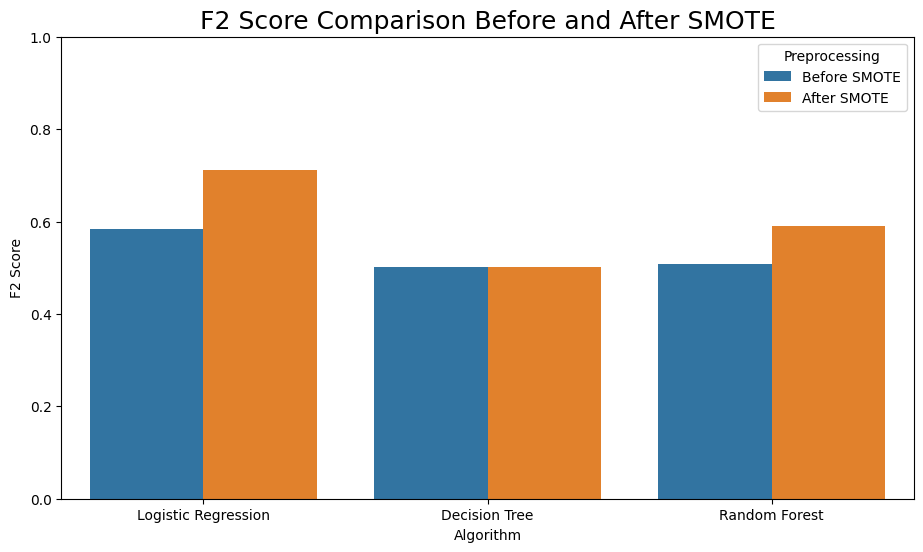

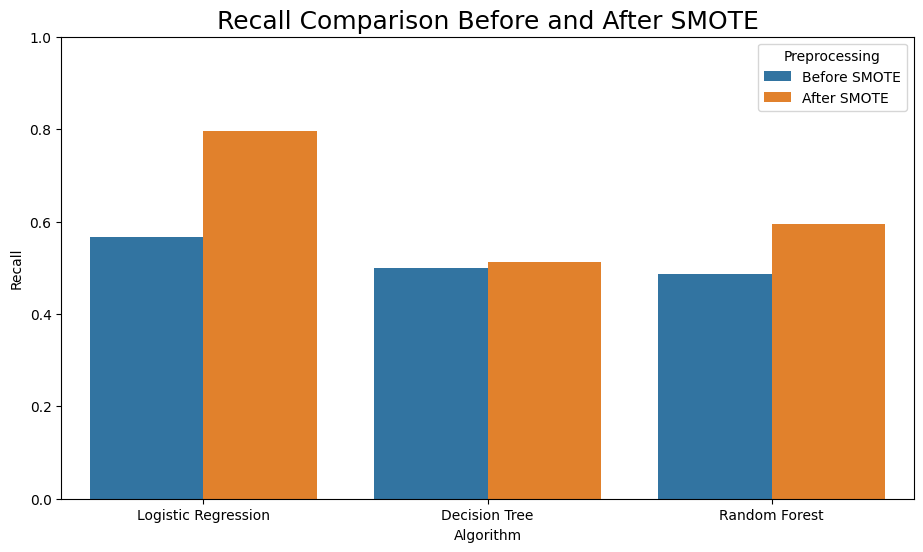

In [82]:
# Visualize the results and compare the baseline algorithms----------------------------------

# =======================================================================================================================
# Sort results based on the right classification metric:
# (Accuracy/ROC_AUC / Precision/Recall/F1/F2 scores)

# Since we have class imbalance. When we look into the business challenge,
# our false negatives will be costly and hence we need to Keep an eye onto the Precision, Recall & F2 score besides accuracy
# =======================================================================================================================

results_sm = results_sm.sort_values(
    ["Precision", "Recall", "F2 Score"],
    ascending = False
)

print (results_sm)

comparison_results = pd.concat(
    [
        results.assign(Preprocessing="Before SMOTE"),
        results_sm.assign(Preprocessing="After SMOTE")
    ],
    ignore_index=True
)

plt.figure(figsize=(11, 6))
sns.barplot(
    data=comparison_results,
    x="Algorithm",
    y="F2 Score",
    hue="Preprocessing"
)

plt.title("F2 Score Comparison Before and After SMOTE", fontsize=18)
plt.xlabel("Algorithm")
plt.ylabel("F2 Score")
plt.ylim(0, 1)
plt.legend(title="Preprocessing")
plt.show()

plt.figure(figsize=(11, 6))
sns.barplot(
    data=comparison_results,
    x="Algorithm",
    y="Recall",
    hue="Preprocessing"
)

plt.title("Recall Comparison Before and After SMOTE", fontsize=18)
plt.xlabel("Algorithm")
plt.ylabel("Recall")
plt.ylim(0, 1)
plt.legend(title="Preprocessing")
plt.show()

## Train & Evaluate Chosen Model

,Chosen Model,ROC AUC,Accuracy,Precision,Recall,F1 Score,F2 Score
0,Logistic Regression,0.8403,0.7353,0.5008,0.7968,0.6151,0.7126


Classification Report
              precision    recall  f1-score   support

           0       0.91      0.71      0.80      1035
           1       0.50      0.80      0.62       374

    accuracy                           0.74      1409
   macro avg       0.70      0.75      0.71      1409
weighted avg       0.80      0.74      0.75      1409



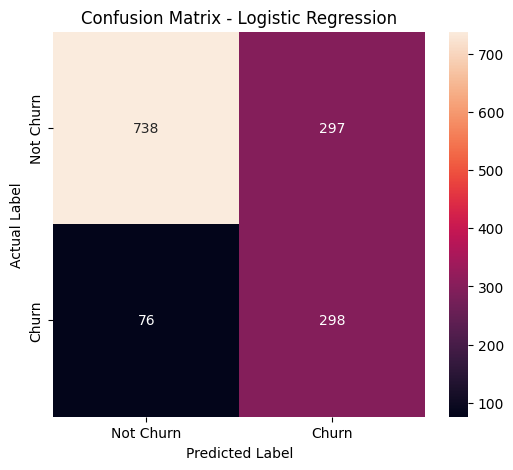

In [84]:
# Train & evaluate Chosen Model---------------------------------------------
# Model terbaik dipilih berdasarkan F2 Score, Recall, dan ROC AUC.
# F2 Score diberi prioritas karena kasus churn lebih sensitif terhadap false negative.

from sklearn.metrics import classification_report

# Fit Chosen Model on the Training dataset
best_model_name = results_sm.sort_values(
    by=["F2 Score", "Recall", "ROC AUC"],
    ascending=False
).iloc[0]["Algorithm"]

chosen_model = models_eval_task2[best_model_name]

chosen_model.fit(X_train_smote, y_train_smote)

# Predict the Test set results
y_pred_chosen = chosen_model.predict(X_test_task2_scaled)
y_proba_chosen = chosen_model.predict_proba(X_test_task2_scaled)[:, 1]

chosen_metrics = pd.DataFrame([{
    "Chosen Model": best_model_name,
    "ROC AUC": round(roc_auc_score(y_test_task2, y_proba_chosen), 4),
    "Accuracy": round(accuracy_score(y_test_task2, y_pred_chosen), 4),
    "Precision": round(precision_score(y_test_task2, y_pred_chosen, zero_division=0), 4),
    "Recall": round(recall_score(y_test_task2, y_pred_chosen, zero_division=0), 4),
    "F1 Score": round(f1_score(y_test_task2, y_pred_chosen, zero_division=0), 4),
    "F2 Score": round(fbeta_score(y_test_task2, y_pred_chosen, beta=2, zero_division=0), 4)
}])

display(chosen_metrics)

print("Classification Report")
print(classification_report(y_test_task2, y_pred_chosen, zero_division=0))

cm = confusion_matrix(y_test_task2, y_pred_chosen)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=["Not Churn", "Churn"],
    yticklabels=["Not Churn", "Churn"]
)

plt.title("Confusion Matrix - {}".format(best_model_name))
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.show()


<Figure size 800x600 with 0 Axes>

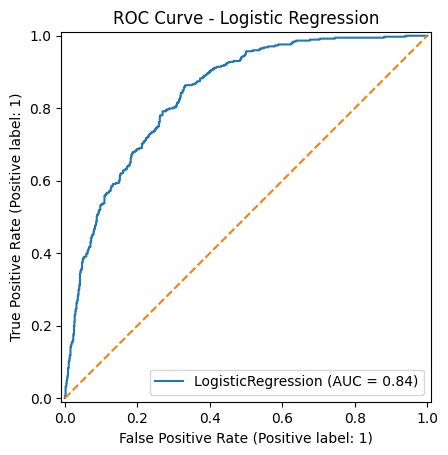

In [85]:
# Evaluate the model using ROC Graph
from sklearn.metrics import RocCurveDisplay

plt.figure(figsize=(8, 6))
RocCurveDisplay.from_estimator(
    chosen_model,
    X_test_task2_scaled,
    y_test_task2
)

plt.plot([0, 1], [0, 1], linestyle="--")
plt.title("ROC Curve - {}".format(best_model_name))
plt.show()


##Analysis

---



In [86]:
print("Result Before Oversampling:")
display(results)

print("\nResult After Oversampling:")
display(results_sm)

print("\nChosen Model:")
display(chosen_metrics)

Result Before Oversampling:


,Algorithm,ROC AUC,Accuracy,Precision,Recall,F1 Score,F2 Score
0,Logistic Regression,0.8415,0.8070,0.6584,0.5668,0.6092,0.5831
1,Decision Tree,0.6633,0.7402,0.5109,0.5000,0.5054,0.5021
2,Random Forest,0.8240,0.7807,0.6087,0.4866,0.5409,0.5070



Result After Oversampling:


,Algorithm,ROC AUC,Accuracy,Precision,Recall,F1 Score,F2 Score
1,Random Forest,0.8206,0.7764,0.5766,0.5936,0.5850,0.5901
0,Logistic Regression,0.8403,0.7353,0.5008,0.7968,0.6151,0.7126
2,Decision Tree,0.6478,0.7111,0.4604,0.5134,0.4855,0.5018



Chosen Model:


,Chosen Model,ROC AUC,Accuracy,Precision,Recall,F1 Score,F2 Score
0,Logistic Regression,0.8403,0.7353,0.5008,0.7968,0.6151,0.7126


Apa insight yang bisa didapat dengan handling data imbalance pada data diatas? Teknik apa yang anda gunakan? Jelaskan!

Answer:

1. Data churn memiliki distribusi kelas yang tidak seimbang. Jumlah pelanggan **Not Churn (0)** lebih besar daripada pelanggan **Churn (1)**. Jika model dilatih tanpa penanganan imbalance, model cenderung lebih mudah memprediksi kelas mayoritas. Dampaknya, nilai accuracy bisa terlihat baik, tetapi kemampuan model mendeteksi pelanggan churn dapat rendah.

2. Teknik yang digunakan adalah **SMOTE Oversampling**. SMOTE membuat data sintetis untuk kelas minoritas pada training set. Teknik ini hanya diterapkan pada **training set**, bukan pada test set. Tujuannya agar proses evaluasi tetap memakai data asli dan tidak terjadi data leakage.

3. Setelah SMOTE, model mendapat jumlah contoh kelas churn yang lebih seimbang. Hal ini membantu model mengenali pola pelanggan yang berpotensi churn. Dalam konteks bisnis, metrik **Recall** dan **F2 Score** penting karena perusahaan perlu mengurangi pelanggan churn yang tidak terdeteksi. F2 Score lebih relevan karena memberi bobot lebih besar pada Recall daripada Precision.

4. Jika setelah SMOTE nilai Recall dan F2 Score meningkat, berarti preprocessing imbalance berhasil membantu model menangkap lebih banyak pelanggan churn. Namun, Precision bisa turun karena model menjadi lebih agresif memprediksi churn. Kondisi ini masih wajar dalam kasus churn prediction, selama perusahaan memang ingin memprioritaskan deteksi dini pelanggan berisiko churn.

5. Model terbaik dipilih berdasarkan kombinasi **F2 Score**, **Recall**, dan **ROC AUC**. Pemilihan ini lebih sesuai daripada hanya memakai Accuracy, karena Accuracy kurang representatif untuk dataset yang tidak seimbang.
